# Phase 2 v5: Feature Engineering (No `using_phone`)

### What changed from v4
- Drops the `using_phone` class from the pose classifier
- Uses **target person only** for suspicious clips
- Uses a small sample of people from pure `normal` clips only
- Replaces the broad active-segment detector with a **peak-centered burst detector**
- Writes a fresh checkpoint so stale 7-class features are not reused


---
## 1. Setup

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'numpy', 'pandas', 'matplotlib', 'seaborn', 'scikit-learn'])
print('Dependencies ready.')

Dependencies ready.


In [2]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('Imports done.')

Imports done.


In [3]:
#  UPDATE THIS PATH                                          

DATA_DIR = '/home/sagemaker-user/exam_proctoring_dataset'

POSES_DIR  = os.path.join(DATA_DIR, 'poses')
LABELS_CSV = os.path.join(DATA_DIR, 'clip_labels_master.csv')
SUMMARY_CSV= os.path.join(DATA_DIR, 'poses', 'extraction_summary.csv')
QUALITY_CSV= os.path.join(DATA_DIR, 'poses', 'pose_quality_report.csv')
OUTPUT_DIR = os.path.join(DATA_DIR, 'training_outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

FEATURES_CHECKPOINT = os.path.join(OUTPUT_DIR, 'features_v5_no_phone_checkpoint.pkl')

# Config
WINDOW_SIZE_SEC   = 3.0
WINDOW_STRIDE_SEC = 1.0
MIN_VISIBILITY    = 0.5
ACTIVE_THRESHOLD  = 0.6
MAX_NORMAL_PEOPLE_PER_NORMAL_CLIP = 2   # sample only from pure normal clips

CLASS_NAMES = ['normal','looking_sideways','leaning_to_neighbor',
               'talking_to_neighbor','looking_down','passing_note']

# Active-segment tuning
MIN_ACTIVE_SEC = 2.5
MAX_ACTIVE_SEC = 5.0
SMOOTH_SEC     = 0.35
ACTIVE_PAD_SEC = 0.25

SEED = 42
np.random.seed(SEED)

def save_checkpoint(data, path):
    with open(path, 'wb') as f: pickle.dump(data, f)
    print(f'Saved: {path} ({os.path.getsize(path)/1024/1024:.1f} MB)')

def load_checkpoint(path):
    if os.path.exists(path):
        with open(path, 'rb') as f: data = pickle.load(f)
        print(f'CHECKPOINT FOUND: {path}')
        return data
    return None

for p, n in [(POSES_DIR,'Poses'),(LABELS_CSV,'Labels')]:
    print(f'  {n}: {"FOUND" if os.path.exists(p) else "MISSING"}')

  Poses: FOUND
  Labels: FOUND


---
## 2. Load Data

In [4]:
df_labels = pd.read_csv(LABELS_CSV, encoding='utf-8-sig')
df_labels = df_labels[df_labels['review_status'].str.strip() == 'complete'].copy()

# Drop using_phone from the pose model.
df_labels = df_labels[df_labels['behavior_class'] != 'using_phone'].copy()

df_summary = pd.read_csv(SUMMARY_CSV)
df_labels['clip_stem'] = df_labels['clip_name'].str.replace('.mp4', '', regex=False)
df_summary['clip_stem'] = df_summary['clip_name'].str.replace('.mp4', '', regex=False)

df = df_labels.merge(
    df_summary[['clip_stem','total_frames','sampled_frames','fps','avg_people_detected']],
    on='clip_stem', how='inner'
)

print(f'Clips after dropping using_phone: {len(df)}')
print(f'\nClass distribution:')
print(df['behavior_class'].value_counts().to_string())

Clips after dropping using_phone: 339

Class distribution:
behavior_class
normal                 104
leaning_to_neighbor     63
looking_sideways        55
talking_to_neighbor     46
looking_down            42
passing_note            29


---
## 3. Improved Feature Functions 


In [5]:
def kp_to_frame_coords(kp, bbox):
    """
    Convert crop-normalised keypoints back to frame pixel coordinates.
    
    Args:
        kp:   (33, 4) - x, y, z, visibility (x,y normalised to crop 0-1)
        bbox: (4,) - x1, y1, x2, y2 in frame pixels
    
    Returns:
        (33, 4) - x, y now in frame pixels; z and visibility unchanged
    """
    result = kp.copy()
    x1, y1, x2, y2 = bbox
    w = x2 - x1
    h = y2 - y1
    if w > 0 and h > 0:
        result[:, 0] = x1 + kp[:, 0] * w  # x in frame pixels
        result[:, 1] = y1 + kp[:, 1] * h  # y in frame pixels
    return result

print('Frame coordinate converter ready.')

Frame coordinate converter ready.


In [6]:
def safe_angle(v1, v2):
    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    if n1 < 1e-6 or n2 < 1e-6: return 0.0
    cos = np.clip(np.dot(v1, v2) / (n1*n2), -1.0, 1.0)
    return np.degrees(np.arccos(cos))


def compute_frame_features_v2(kp_frame, prev_kp_frame, ref_shoulder_w):
    """
    Compute features from keypoints in FRAME coordinates.
    
    Args:
        kp_frame:       (33, 4) - keypoints in frame pixel coords
        prev_kp_frame:  (33, 4) or None - previous frame
        ref_shoulder_w: float - median shoulder width for this person (pixels)
    
    Returns: dict of feature_name -> float
    """
    feat = {}
    vis = kp_frame[:, 3]
    sw = max(ref_shoulder_w, 1.0)  # prevent division by zero
    
    def pt(idx):
        return kp_frame[idx, :2] if vis[idx] >= MIN_VISIBILITY else None
    
    nose=pt(0); l_ear=pt(7); r_ear=pt(8); mouth_l=pt(9); mouth_r=pt(10)
    l_sh=pt(11); r_sh=pt(12); l_el=pt(13); r_el=pt(14)
    l_wr=pt(15); r_wr=pt(16); l_hip=pt(23); r_hip=pt(24)
    
    mid_sh = (l_sh + r_sh) / 2 if (l_sh is not None and r_sh is not None) else None
    mid_hip = (l_hip + r_hip) / 2 if (l_hip is not None and r_hip is not None) else None
    
    # ── F1: Head turn (pixels / shoulder_width) ──
    # Positive = nose right of shoulder midpoint
    if nose is not None and mid_sh is not None:
        feat['head_turn'] = (nose[0] - mid_sh[0]) / sw
    else:
        feat['head_turn'] = 0.0
    
    # ── F2: Head turn velocity (change from prev frame) ──
    # High values = rapid head movement
    feat['head_turn_vel'] = 0.0
    if prev_kp_frame is not None and nose is not None and mid_sh is not None:
        pv = prev_kp_frame[:, 3]
        if pv[0] >= MIN_VISIBILITY and pv[11] >= MIN_VISIBILITY and pv[12] >= MIN_VISIBILITY:
            prev_nose = prev_kp_frame[0, :2]
            prev_mid = (prev_kp_frame[11, :2] + prev_kp_frame[12, :2]) / 2
            prev_ht = (prev_nose[0] - prev_mid[0]) / sw
            feat['head_turn_vel'] = abs(feat['head_turn'] - prev_ht)
    
    # ── F3: Nose-shoulder vertical distance (pixels / shoulder_width) ──
    # Larger = head more dropped (looking_down)
    if nose is not None and mid_sh is not None:
        feat['nose_shoulder_dist'] = (nose[1] - mid_sh[1]) / sw
    else:
        feat['nose_shoulder_dist'] = 0.0
    
    # ── F4: Torso lean angle (degrees) ──
    if mid_sh is not None and mid_hip is not None:
        torso = mid_hip - mid_sh
        angle = safe_angle(torso, np.array([0, 1]))
        feat['torso_lean'] = (1.0 if torso[0] > 0 else -1.0) * angle
    else:
        feat['torso_lean'] = 0.0
    
    # ── F5: Shoulder tilt (degrees from horizontal) ──
    if l_sh is not None and r_sh is not None:
        feat['shoulder_tilt'] = safe_angle(r_sh - l_sh, np.array([1, 0]))
    else:
        feat['shoulder_tilt'] = 0.0
    
    # ── F6-F7: Wrist drop (pixels below shoulder / sw) ──
    feat['l_wrist_drop'] = ((l_wr[1] - mid_sh[1]) / sw) if (l_wr is not None and mid_sh is not None) else 0.0
    feat['r_wrist_drop'] = ((r_wr[1] - mid_sh[1]) / sw) if (r_wr is not None and mid_sh is not None) else 0.0
    
    # ── F8-F9: Wrist lateral extent (pixels beyond shoulder / sw) ──
    feat['l_wrist_extent'] = ((l_sh[0] - l_wr[0]) / sw) if (l_wr is not None and l_sh is not None) else 0.0
    feat['r_wrist_extent'] = ((r_wr[0] - r_sh[0]) / sw) if (r_wr is not None and r_sh is not None) else 0.0
    
    # ── F10: Wrist below desk plane (how far below hip level / sw) ──
    # Positive = wrist below hip (reaching under desk for phone)
    feat['wrist_below_desk'] = 0.0
    if mid_hip is not None:
        drops = []
        if l_wr is not None: drops.append((l_wr[1] - mid_hip[1]) / sw)
        if r_wr is not None: drops.append((r_wr[1] - mid_hip[1]) / sw)
        if drops: feat['wrist_below_desk'] = max(drops)
    
    # ── F11: Ear asymmetry (difference, not ratio) ──
    # High absolute value = head turned (one ear hidden)
    l_ev = vis[7] if vis[7] >= 0.1 else 0.0
    r_ev = vis[8] if vis[8] >= 0.1 else 0.0
    feat['ear_asymmetry'] = abs(l_ev - r_ev)
    
    # ── F12: Mouth movement (frame-to-frame) ──
    feat['mouth_movement'] = 0.0
    if prev_kp_frame is not None and mouth_l is not None and mouth_r is not None:
        pv = prev_kp_frame[:, 3]
        if pv[9] >= MIN_VISIBILITY and pv[10] >= MIN_VISIBILITY:
            dl = np.linalg.norm(mouth_l - prev_kp_frame[9, :2])
            dr = np.linalg.norm(mouth_r - prev_kp_frame[10, :2])
            feat['mouth_movement'] = (dl + dr) / (2 * sw)
    
    # ── F13: Body movement (frame-to-frame, normalised) ──
    feat['body_movement'] = 0.0
    if prev_kp_frame is not None:
        mv = 0.0; cnt = 0
        for idx in [0, 11, 12, 15, 16]:
            if vis[idx] >= MIN_VISIBILITY and prev_kp_frame[idx, 3] >= MIN_VISIBILITY:
                mv += np.linalg.norm(kp_frame[idx, :2] - prev_kp_frame[idx, :2])
                cnt += 1
        if cnt > 0: feat['body_movement'] = mv / (cnt * sw)
    
    return feat


FEATURE_NAMES_V2 = [
    'head_turn', 'head_turn_vel', 'nose_shoulder_dist',
    'torso_lean', 'shoulder_tilt',
    'l_wrist_drop', 'r_wrist_drop', 'l_wrist_extent', 'r_wrist_extent',
    'wrist_below_desk', 'ear_asymmetry', 'mouth_movement', 'body_movement',
]
NUM_BASE = len(FEATURE_NAMES_V2)
print(f'Base features per frame: {NUM_BASE} (was 11 in v1, now 13)')

Base features per frame: 13 (was 11 in v1, now 13)


---
## 4. Helper Functions

In [7]:
def parse_target_seat(target_seat):
    """Return (row_letter, zero_based_position) or None for blank/NaN/invalid seats."""
    if target_seat is None:
        return None
    s = str(target_seat).strip().upper()
    if s in ('', 'NAN', 'NONE'):
        return None
    if len(s) < 2:
        return None
    row = s[0]
    pos_str = s[1:]
    if row not in ('A', 'B') or not pos_str.isdigit():
        return None
    pos = int(pos_str) - 1
    if pos < 0:
        return None
    return row, pos


def identify_target_person(bboxes, num_detected, target_seat):
    seat = parse_target_seat(target_seat)
    if seat is None or num_detected < 1:
        return -1

    n = int(num_detected)
    centers = [(i, (bboxes[i][0]+bboxes[i][2])/2, (bboxes[i][1]+bboxes[i][3])/2) for i in range(n)]
    cy_med = np.median([c[2] for c in centers])
    front = sorted([c for c in centers if c[2] >= cy_med], key=lambda c: c[1])
    back  = sorted([c for c in centers if c[2] <  cy_med], key=lambda c: c[1])

    row, pos = seat
    if row == 'A' and pos < len(front):
        return front[pos][0]
    if row == 'B' and pos < len(back):
        return back[pos][0]
    return -1


def compute_median_shoulder_width(kps_person, bboxes_person):
    """Median shoulder width in frame pixels for stable normalisation."""
    widths = []
    for f in range(kps_person.shape[0]):
        vis = kps_person[f, :, 3]
        if vis[11] >= MIN_VISIBILITY and vis[12] >= MIN_VISIBILITY:
            kp_f = kp_to_frame_coords(kps_person[f], bboxes_person[f])
            w = np.linalg.norm(kp_f[12, :2] - kp_f[11, :2])
            if w > 5:
                widths.append(w)
    return np.median(widths) if widths else 50.0


def robust_z(x):
    x = np.asarray(x, dtype=np.float32)
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + 1e-6
    return (x - med) / (1.4826 * mad)


def smooth_signal(x, k):
    if k <= 1:
        return x
    k = int(max(1, k))
    return np.convolve(x, np.ones(k) / k, mode='same')


def contiguous_runs(mask):
    runs = []
    start = None
    for i, v in enumerate(mask):
        if v and start is None:
            start = i
        elif not v and start is not None:
            runs.append((start, i))
            start = None
    if start is not None:
        runs.append((start, len(mask)))
    return runs


def build_class_score(frame_features, behavior_class):
    ff = pd.DataFrame(frame_features)

    if behavior_class == 'looking_sideways':
        s = 0.70*np.abs(robust_z(ff['head_turn'])) + 0.30*np.abs(robust_z(ff['ear_asymmetry']))

    elif behavior_class == 'looking_down':
        s = 0.80*robust_z(ff['nose_shoulder_dist']) + 0.20*robust_z(ff['head_turn_vel'])

    elif behavior_class == 'leaning_to_neighbor':
        s = 0.70*np.abs(robust_z(ff['torso_lean'])) + 0.30*robust_z(ff['shoulder_tilt'])

    elif behavior_class == 'talking_to_neighbor':
        s = (
            0.55*robust_z(ff['mouth_movement']) +
            0.30*np.abs(robust_z(ff['head_turn'])) +
            0.15*robust_z(ff['head_turn_vel'])
        )

    elif behavior_class == 'passing_note':
        wrist_extent = np.maximum(ff['l_wrist_extent'].values, ff['r_wrist_extent'].values)
        s = 0.70*robust_z(wrist_extent) + 0.30*robust_z(ff['body_movement'])

    else:
        s = robust_z(ff['body_movement'])

    return np.asarray(s, dtype=np.float32)


def detect_active_segment(frame_features, behavior_class, fps):
    n = len(frame_features)
    if behavior_class == 'normal' or n == 0:
        return 0, n

    score = build_class_score(frame_features, behavior_class)
    score = np.nan_to_num(score, nan=0.0, posinf=0.0, neginf=0.0)

    smooth_k = max(1, int(round(SMOOTH_SEC * fps)))
    score = smooth_signal(score, smooth_k)

    peak_idx = int(np.argmax(score))
    peak_val = float(score[peak_idx])

    thr = max(np.percentile(score, 80), peak_val * 0.60)
    active_mask = score >= thr
    runs = contiguous_runs(active_mask)

    if not runs:
        min_len = int(round(MIN_ACTIVE_SEC * fps))
        s = max(0, peak_idx - min_len // 2)
        e = min(n, s + min_len)
        s = max(0, e - min_len)
        return s, e

    peak_run = None
    for s, e in runs:
        if s <= peak_idx < e:
            peak_run = (s, e)
            break
    if peak_run is None:
        peak_run = max(runs, key=lambda r: float(np.mean(score[r[0]:r[1]])))

    s, e = peak_run

    pad = int(round(ACTIVE_PAD_SEC * fps))
    s = max(0, s - pad)
    e = min(n, e + pad)

    min_len = int(round(MIN_ACTIVE_SEC * fps))
    max_len = int(round(MAX_ACTIVE_SEC * fps))

    if (e - s) < min_len:
        c = peak_idx
        s = max(0, c - min_len // 2)
        e = min(n, s + min_len)
        s = max(0, e - min_len)

    if (e - s) > max_len:
        local = score[s:e]
        if len(local) > max_len:
            best_start_rel = int(np.argmax(np.convolve(local, np.ones(max_len), mode='valid')))
            s = s + best_start_rel
            e = s + max_len

    return int(s), int(e)

In [8]:
AGG_NAMES = ['mean', 'std', 'max', 'min', 'range', 'zero_crossings']
NUM_AGG = NUM_BASE * len(AGG_NAMES)
FULL_FEAT_NAMES = [f'{f}_{a}' for f in FEATURE_NAMES_V2 for a in AGG_NAMES]

def aggregate_window(ff_arr):
    """
    Aggregate a window of per-frame features into a single vector.

    Args:
        ff_arr: numpy array of shape (window_frames, NUM_BASE)

    Returns:
        numpy array of shape (NUM_AGG,)
    """
    if ff_arr is None or len(ff_arr) == 0:
        return np.zeros(NUM_AGG, dtype=np.float32)

    ff_arr = np.asarray(ff_arr, dtype=np.float32)
    if ff_arr.ndim != 2 or ff_arr.shape[1] != NUM_BASE:
        raise ValueError(f'aggregate_window expected shape (T, {NUM_BASE}), got {ff_arr.shape}')

    result = []
    for i in range(ff_arr.shape[1]):
        s = ff_arr[:, i]
        s = np.nan_to_num(s, nan=0.0, posinf=0.0, neginf=0.0)
        centered = s - np.mean(s)

        result.extend([
            float(np.mean(s)),
            float(np.std(s)),
            float(np.max(s)),
            float(np.min(s)),
            float(np.max(s) - np.min(s)),
            float(np.sum(np.diff(np.sign(centered)) != 0)) if len(s) > 1 else 0.0,
        ])

    return np.array(result, dtype=np.float32)

print(f'Window aggregation ready: {NUM_BASE} base × {len(AGG_NAMES)} stats = {NUM_AGG} features')

Window aggregation ready: 13 base × 6 stats = 78 features


---
## 5. Explore a Single Clip 


Clip: LE03_leaning_to_neighbor_take04 (leaning_to_neighbor, seat A4)
Target person: P7
Reference shoulder width: 76.8 pixels


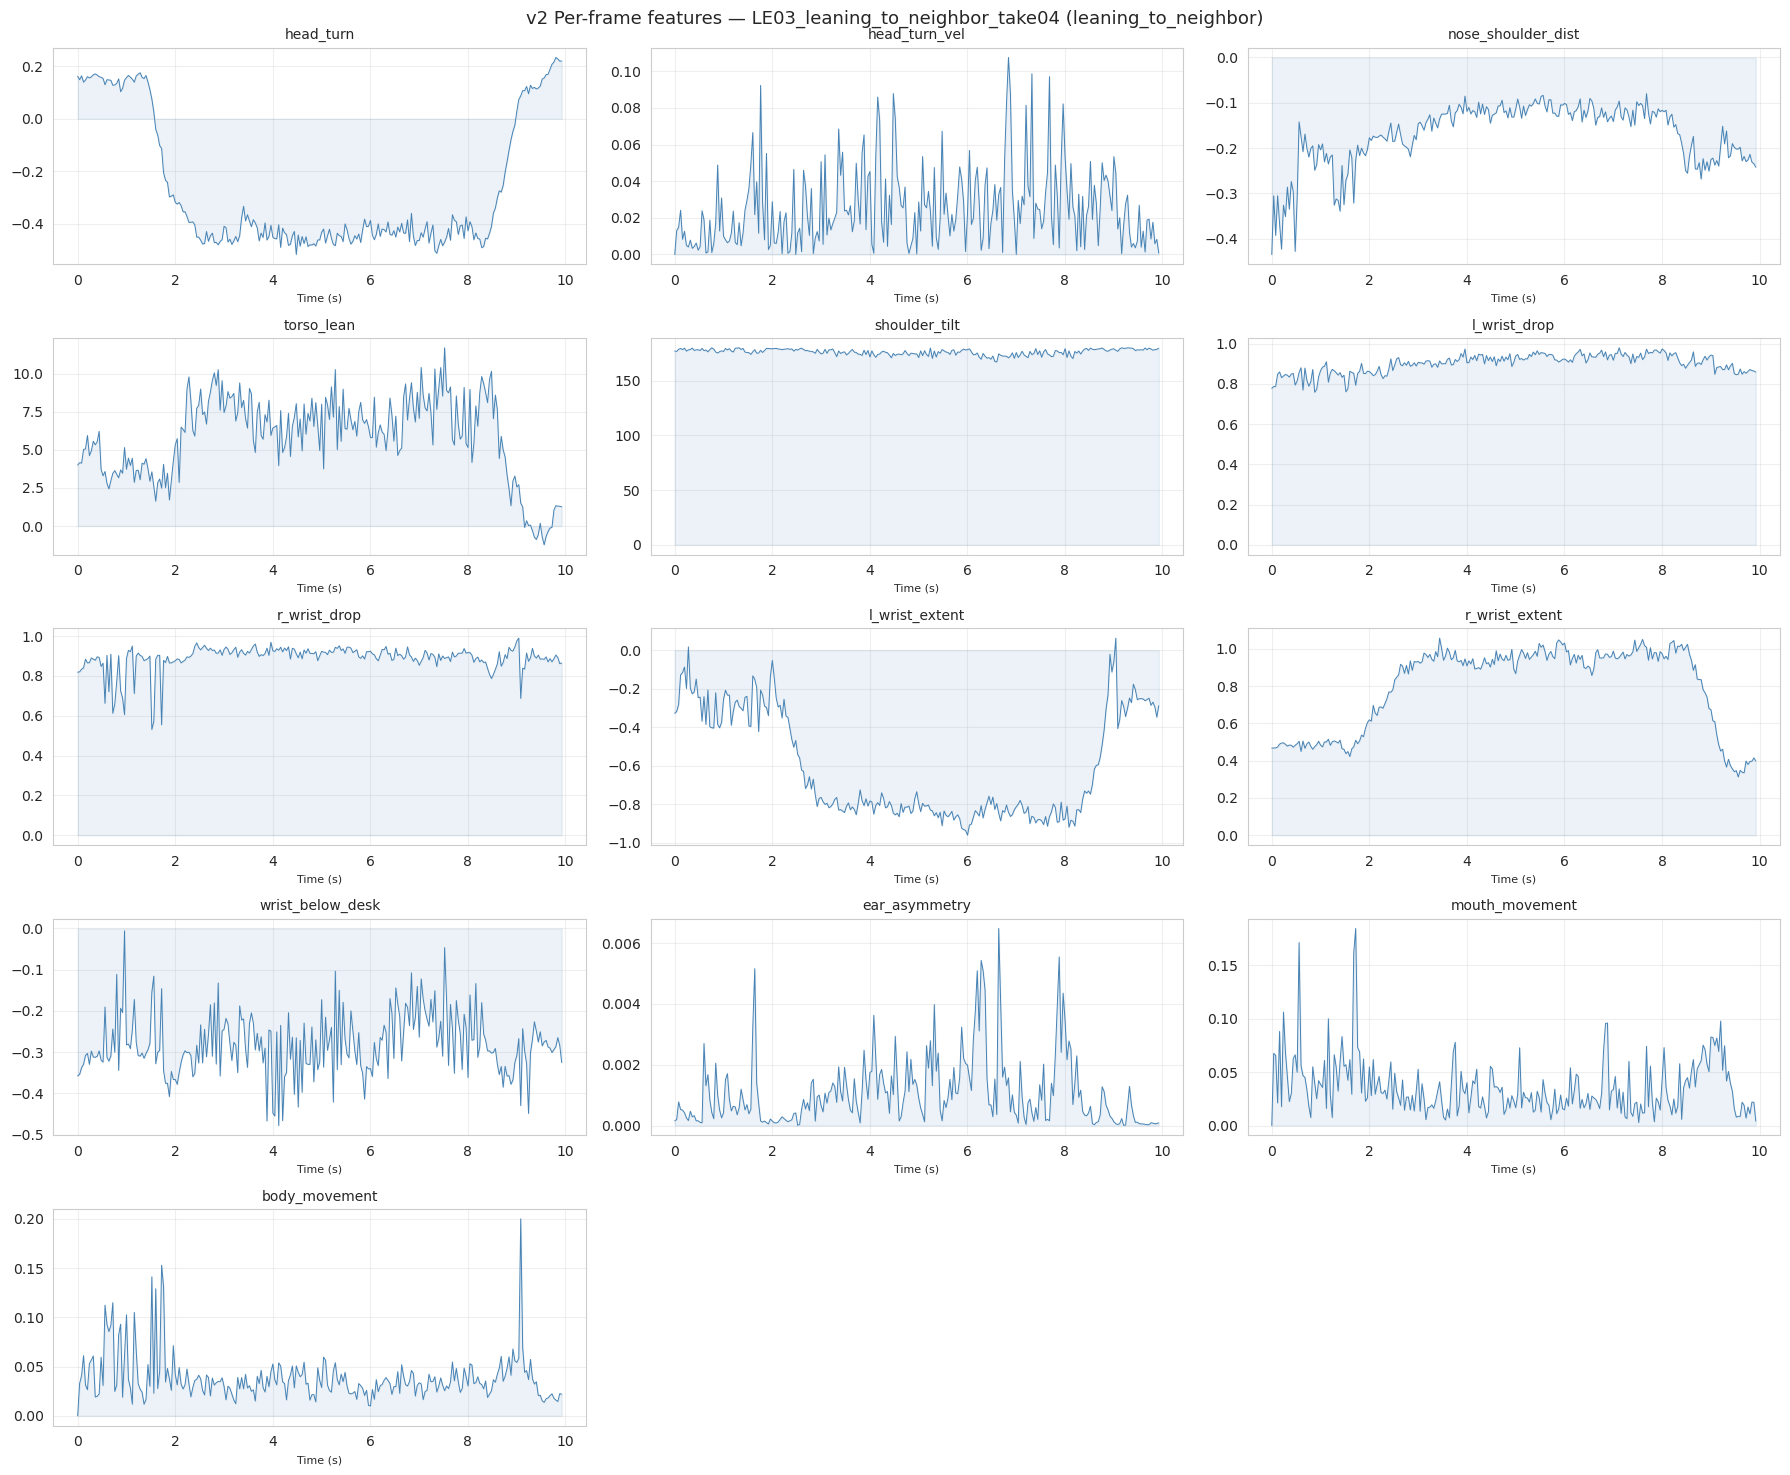

In [9]:
EXPLORE_CLIP = 'LE03_leaning_to_neighbor_take04'

npz = np.load(os.path.join(POSES_DIR, f'{EXPLORE_CLIP}.npz'), allow_pickle=True)
ex_kp = npz['keypoints']; ex_bb = npz['bbox']; ex_nd = npz['num_detected']
ex_beh = str(npz['behavior_class'])
ex_seat_raw = npz['target_seat']
ex_seat = None if str(ex_seat_raw).strip().upper() in ('', 'NAN', 'NONE') else str(ex_seat_raw).strip().upper()
ex_fps = float(npz['fps'])

mid = ex_kp.shape[0] // 2
ex_tidx = identify_target_person(ex_bb[mid], ex_nd[mid], ex_seat)
if ex_tidx < 0: ex_tidx = 0

# Compute median shoulder width for this person
ex_ref_sw = compute_median_shoulder_width(ex_kp[:, ex_tidx, :, :], ex_bb[:, ex_tidx, :])

print(f'Clip: {EXPLORE_CLIP} ({ex_beh}, seat {ex_seat})')
print(f'Target person: P{ex_tidx+1}')
print(f'Reference shoulder width: {ex_ref_sw:.1f} pixels')

# Compute v2 features
ex_ff = []
for f in range(ex_kp.shape[0]):
    kp_f = kp_to_frame_coords(ex_kp[f, ex_tidx], ex_bb[f, ex_tidx])
    prev_f = kp_to_frame_coords(ex_kp[f-1, ex_tidx], ex_bb[f-1, ex_tidx]) if f > 0 else None
    ex_ff.append(compute_frame_features_v2(kp_f, prev_f, ex_ref_sw))

# Plot all features
t = np.arange(len(ex_ff)) / ex_fps
ncols = 3; nrows = (NUM_BASE + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3*nrows))
for i, fn in enumerate(FEATURE_NAMES_V2):
    ax = axes.flat[i]
    sig = [ff[fn] for ff in ex_ff]
    ax.plot(t, sig, color='steelblue', lw=0.7)
    ax.fill_between(t, sig, alpha=0.1, color='steelblue')
    ax.set_title(fn, fontsize=10); ax.set_xlabel('Time (s)', fontsize=8)
    ax.grid(True, alpha=0.3)
for j in range(len(FEATURE_NAMES_V2), len(axes.flat)): axes.flat[j].set_visible(False)
plt.suptitle(f'v2 Per-frame features — {EXPLORE_CLIP} ({ex_beh})', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'v5_no_phone_per_frame_features.png'), dpi=150, bbox_inches='tight')
plt.show()

### Active Segment + Window Labels

Active: 7.5s – 10.0s (2.5s duration)


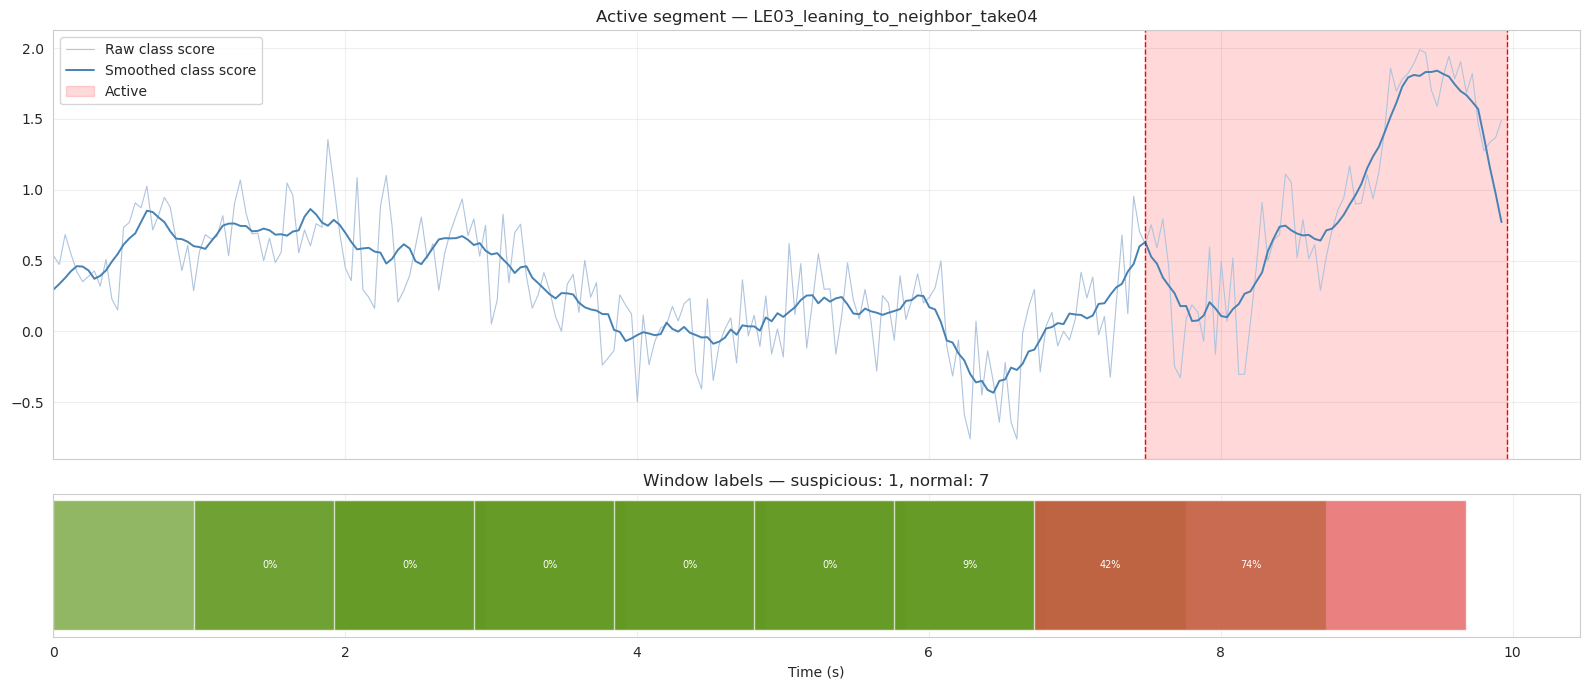

In [10]:
a_s, a_e = detect_active_segment(ex_ff, ex_beh, ex_fps)
print(f'Active: {a_s/ex_fps:.1f}s – {a_e/ex_fps:.1f}s ({(a_e-a_s)/ex_fps:.1f}s duration)')

score = build_class_score(ex_ff, ex_beh)
smooth_k = max(1, int(round(SMOOTH_SEC * ex_fps)))
score_s = smooth_signal(score, smooth_k)

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True, gridspec_kw={'height_ratios':[3,1]})
axes[0].plot(t, score, color='lightsteelblue', lw=0.8, label='Raw class score')
axes[0].plot(t, score_s, color='steelblue', lw=1.4, label='Smoothed class score')
axes[0].axvspan(a_s/ex_fps, a_e/ex_fps, alpha=0.15, color='red', label='Active')
axes[0].axvline(a_s/ex_fps, color='red', lw=1, ls='--')
axes[0].axvline(a_e/ex_fps, color='red', lw=1, ls='--')
axes[0].set_title(f'Active segment — {EXPLORE_CLIP}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

wf = int(WINDOW_SIZE_SEC * ex_fps); sf = int(WINDOW_STRIDE_SEC * ex_fps); nf = len(ex_ff)
sus_w = 0; nor_w = 0
for ws in range(0, nf - wf + 1, sf):
    we = ws + wf
    ov = max(0, min(we, a_e) - max(ws, a_s)) / wf
    is_sus = (ex_beh != 'normal' and ov >= ACTIVE_THRESHOLD)
    c = '#E24B4A' if is_sus else '#639922'
    axes[1].barh(0, (we-ws)/ex_fps, left=ws/ex_fps, height=0.6, color=c, alpha=0.7, edgecolor='white', lw=1)
    axes[1].text((ws+we)/2/ex_fps, 0, f'{ov:.0%}', ha='center', va='center', fontsize=7, color='white')
    sus_w += int(is_sus)
    nor_w += int(not is_sus)

axes[1].set_yticks([])
axes[1].set_title(f'Window labels — suspicious: {sus_w}, normal: {nor_w}')
axes[1].set_xlabel('Time (s)')
axes[1].grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Full Feature Extraction


In [11]:
cached = load_checkpoint(FEATURES_CHECKPOINT)

if cached is not None:
    all_features = cached['features']
    all_labels_7 = cached['labels_7class']
    all_labels_2 = cached['labels_binary']
    all_meta = cached['meta']
    print(f'Loaded {len(all_features)} windows from checkpoint.')

else:
    print(f'Extracting v5 features from {len(df)} clips...\n')
    all_features, all_labels_7, all_labels_2, all_meta = [], [], [], []

    for clip_idx, (_, row) in enumerate(df.iterrows()):
        clip_stem = row['clip_stem']
        behavior = row['behavior_class']
        target_seat_raw = row.get('target_seat_id', '')
        target_seat = None if pd.isna(target_seat_raw) else str(target_seat_raw).strip().upper()
        scenario_id = row.get('scenario_id', '')

        if (clip_idx + 1) % 50 == 0 or clip_idx == 0:
            print(f'  [{clip_idx+1}/{len(df)}] {clip_stem} ({behavior})')

        npz_path = os.path.join(POSES_DIR, f'{clip_stem}.npz')
        if not os.path.exists(npz_path):
            continue

        data = np.load(npz_path, allow_pickle=True)
        kps = data['keypoints']; bbs = data['bbox']; nd = data['num_detected']
        fps = float(data['fps']); nf = kps.shape[0]
        wf = int(WINDOW_SIZE_SEC * fps); sf = int(WINDOW_STRIDE_SEC * fps)
        if nf < wf:
            continue

        mid = nf // 2
        target_idx = identify_target_person(bbs[mid], nd[mid], target_seat)

        # People policy:
        # - suspicious clips: target person only
        # - pure normal clips: sample a small number of people
        people = []
        n_det = int(nd[mid])

        if behavior == 'normal':
            normal_candidates = list(range(n_det))
            if normal_candidates:
                chosen = np.random.choice(
                    normal_candidates,
                    size=min(MAX_NORMAL_PEOPLE_PER_NORMAL_CLIP, len(normal_candidates)),
                    replace=False
                )
                for c in chosen:
                    people.append((int(c), 'normal'))
        else:
            if target_idx >= 0:
                people.append((target_idx, behavior))

        for pidx, plabel in people:
            ref_sw = compute_median_shoulder_width(kps[:, pidx, :, :], bbs[:, pidx, :])

            ffl = []
            for f in range(nf):
                if pidx >= int(nd[f]):
                    ffl.append({k: 0.0 for k in FEATURE_NAMES_V2})
                else:
                    kp_f = kp_to_frame_coords(kps[f, pidx], bbs[f, pidx])
                    prev_f = kp_to_frame_coords(kps[f-1, pidx], bbs[f-1, pidx]) if (f > 0 and pidx < int(nd[f-1])) else None
                    ffl.append(compute_frame_features_v2(kp_f, prev_f, ref_sw))

            ff_arr = np.array([[ff[n] for n in FEATURE_NAMES_V2] for ff in ffl], dtype=np.float32)

            if pidx == target_idx and behavior != 'normal':
                act_s, act_e = detect_active_segment(ffl, behavior, fps)
            else:
                act_s, act_e = 0, nf

            act_dur_sec = (act_e - act_s) / fps if fps > 0 else 0.0

            for ws in range(0, nf - wf + 1, sf):
                we = ws + wf
                if plabel == 'normal':
                    wlabel_7 = 'normal'
                else:
                    ov = max(0, min(we, act_e) - max(ws, act_s))
                    wlabel_7 = behavior if (ov / wf) >= ACTIVE_THRESHOLD else 'normal'

                wlabel_2 = 'suspicious' if wlabel_7 != 'normal' else 'normal'

                agg = aggregate_window(ff_arr[ws:we])
                agg = np.nan_to_num(agg, nan=0.0, posinf=0.0, neginf=0.0)

                all_features.append(agg)
                all_labels_7.append(wlabel_7)
                all_labels_2.append(wlabel_2)
                all_meta.append({
                    'clip_stem': clip_stem,
                    'scenario_id': scenario_id,
                    'person_idx': pidx,
                    'is_target': pidx == target_idx,
                    'window_start': ws,
                    'window_end': we,
                    'original_behavior': behavior,
                    'active_start': int(act_s),
                    'active_end': int(act_e),
                    'active_duration_sec': float(act_dur_sec),
                    'fps': float(fps),
                })

    all_features = np.array(all_features, dtype=np.float32)
    all_labels_7 = np.array(all_labels_7)
    all_labels_2 = np.array(all_labels_2)
    save_checkpoint({
        'features': all_features,
        'labels_7class': all_labels_7,
        'labels_binary': all_labels_2,
        'meta': all_meta,
        'feature_names': FEATURE_NAMES_V2,
        'full_feature_names': FULL_FEAT_NAMES,
        'agg_names': AGG_NAMES,
        'class_names': CLASS_NAMES,
    }, FEATURES_CHECKPOINT)

print(f'\nTotal windows: {len(all_features)}')
print(f'Feature shape: {all_features.shape}')
print(f'\n6-class distribution:')
for l, c in zip(*np.unique(all_labels_7, return_counts=True)):
    print(f'  {l}: {c} ({c/len(all_labels_7)*100:.1f}%)')
print(f'\nBinary distribution:')
for l, c in zip(*np.unique(all_labels_2, return_counts=True)):
    print(f'  {l}: {c} ({c/len(all_labels_2)*100:.1f}%)')

Extracting v5 features from 339 clips...

  [1/339] N01_normal_take01 (normal)
  [50/339] HN02_normal_take04 (normal)
  [100/339] HN09_normal_take04 (normal)
  [150/339] L03_looking_sideways_take04 (looking_sideways)
  [200/339] LE02_leaning_to_neighbor_take04 (leaning_to_neighbor)
  [250/339] LE08_leaning_to_neighbor_take07 (leaning_to_neighbor)
  [300/339] LD01_looking_down_take03 (looking_down)
Saved: /home/sagemaker-user/exam_proctoring_dataset/training_outputs/features_v5_no_phone_checkpoint.pkl (1.7 MB)

Total windows: 3496
Feature shape: (3496, 78)

6-class distribution:
  leaning_to_neighbor: 92 (2.6%)
  looking_down: 70 (2.0%)
  looking_sideways: 90 (2.6%)
  normal: 3127 (89.4%)
  passing_note: 48 (1.4%)
  talking_to_neighbor: 69 (2.0%)

Binary distribution:
  normal: 3127 (89.4%)
  suspicious: 369 (10.6%)


In [12]:
meta_df = pd.DataFrame(all_meta)

target_meta = meta_df[meta_df['is_target']].copy()
target_meta = target_meta[target_meta['original_behavior'] != 'normal'].copy()

if len(target_meta) > 0:
    seg_stats = (
        target_meta[['clip_stem', 'original_behavior', 'active_duration_sec']]
        .drop_duplicates()
        .groupby('original_behavior')['active_duration_sec']
        .agg(['count', 'mean', 'min', 'max'])
        .sort_index()
    )
    print('Active-segment duration stats (seconds):')
    display(seg_stats.round(2))
else:
    print('No suspicious target metadata found.')

print('\nTarget windows by original behaviour:')
display(
    meta_df[meta_df['is_target']]['original_behavior']
    .value_counts()
    .sort_index()
    .rename('windows')
    .to_frame()
)

Active-segment duration stats (seconds):


,count,mean,min,max
original_behavior,,,,
leaning_to_neighbor,60,2.48,2.48,2.48
looking_down,40,2.50,2.50,2.50
looking_sideways,54,2.48,2.48,2.48
passing_note,29,2.48,2.48,2.48
talking_to_neighbor,46,2.48,2.48,2.48



Target windows by original behaviour:


,windows
original_behavior,
leaning_to_neighbor,480
looking_down,320
looking_sideways,432
normal,112
passing_note,232
talking_to_neighbor,368


### Feature Distributions (v5, no `using_phone`)

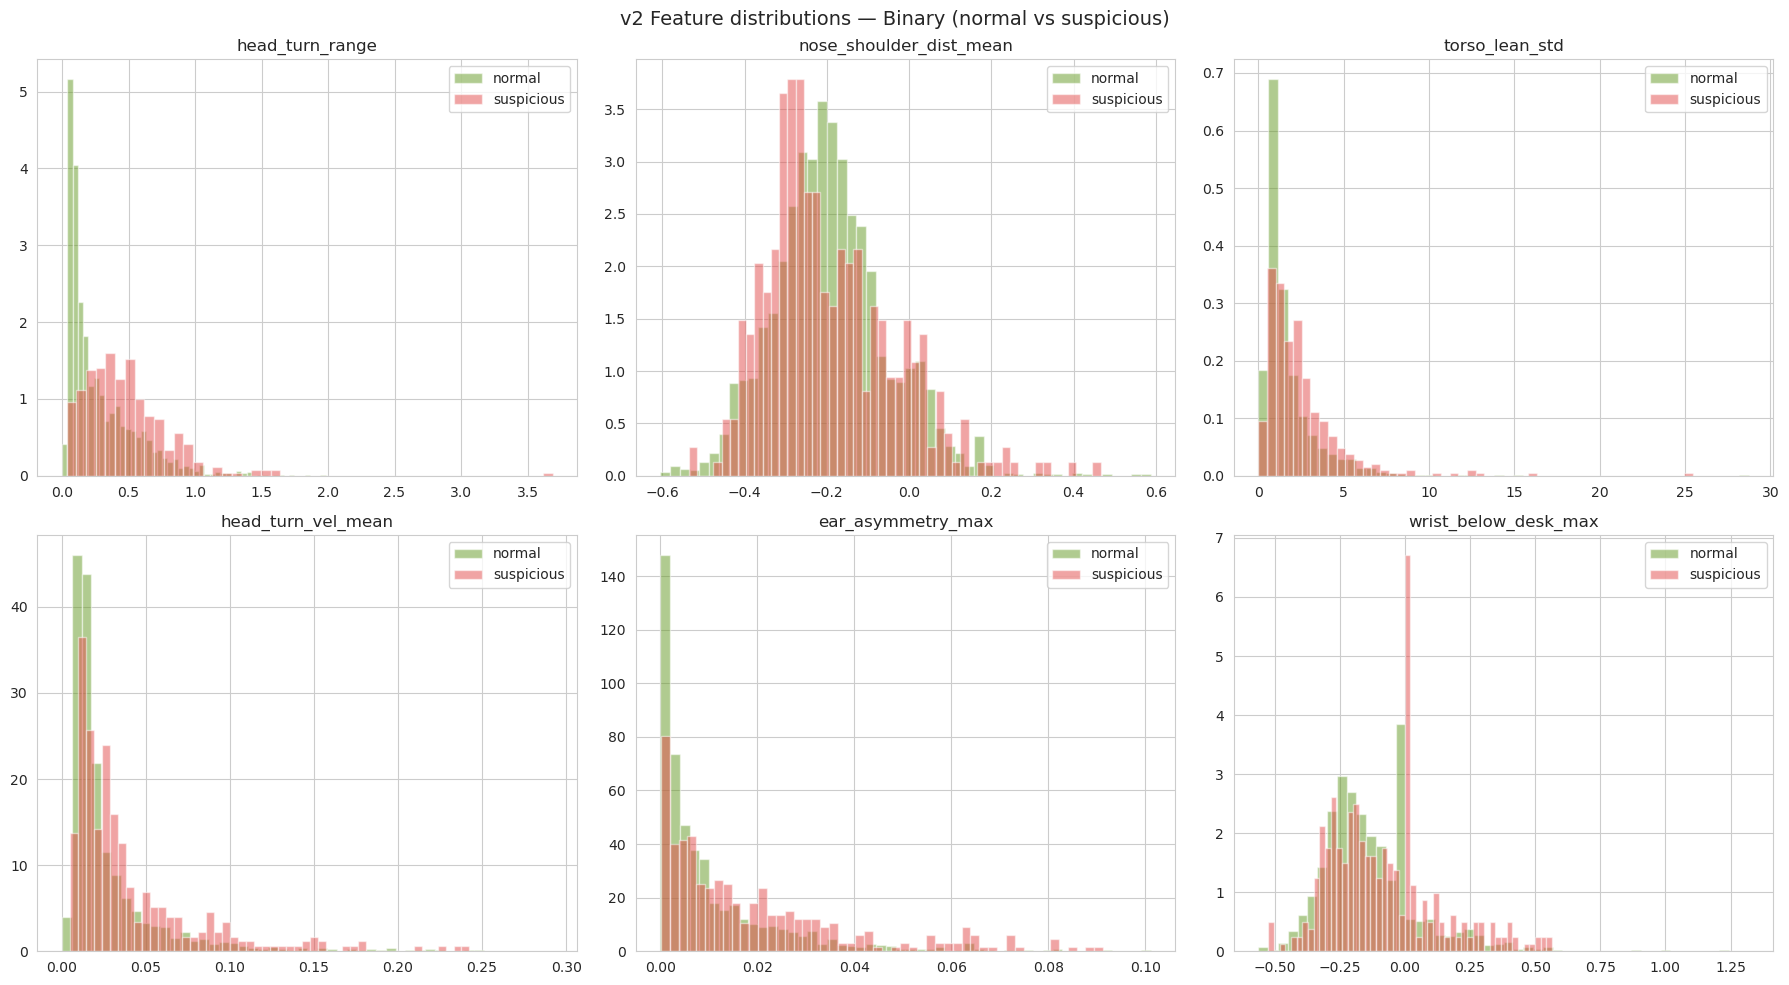

In [13]:
df_feat = pd.DataFrame(all_features, columns=FULL_FEAT_NAMES)
df_feat['label_7'] = all_labels_7
df_feat['label_2'] = all_labels_2

# Binary distributions
key_feats = ['head_turn_range','nose_shoulder_dist_mean','torso_lean_std',
             'head_turn_vel_mean','ear_asymmetry_max','wrist_below_desk_max']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, fn in zip(axes.flat, key_feats):
    for cls in ['normal','suspicious']:
        m = df_feat['label_2'] == cls
        c = '#639922' if cls == 'normal' else '#E24B4A'
        ax.hist(df_feat.loc[m, fn], bins=50, alpha=0.5, label=cls, density=True, color=c)
    ax.set_title(fn); ax.legend()
plt.suptitle('v2 Feature distributions — Binary (normal vs suspicious)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'v2_binary_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

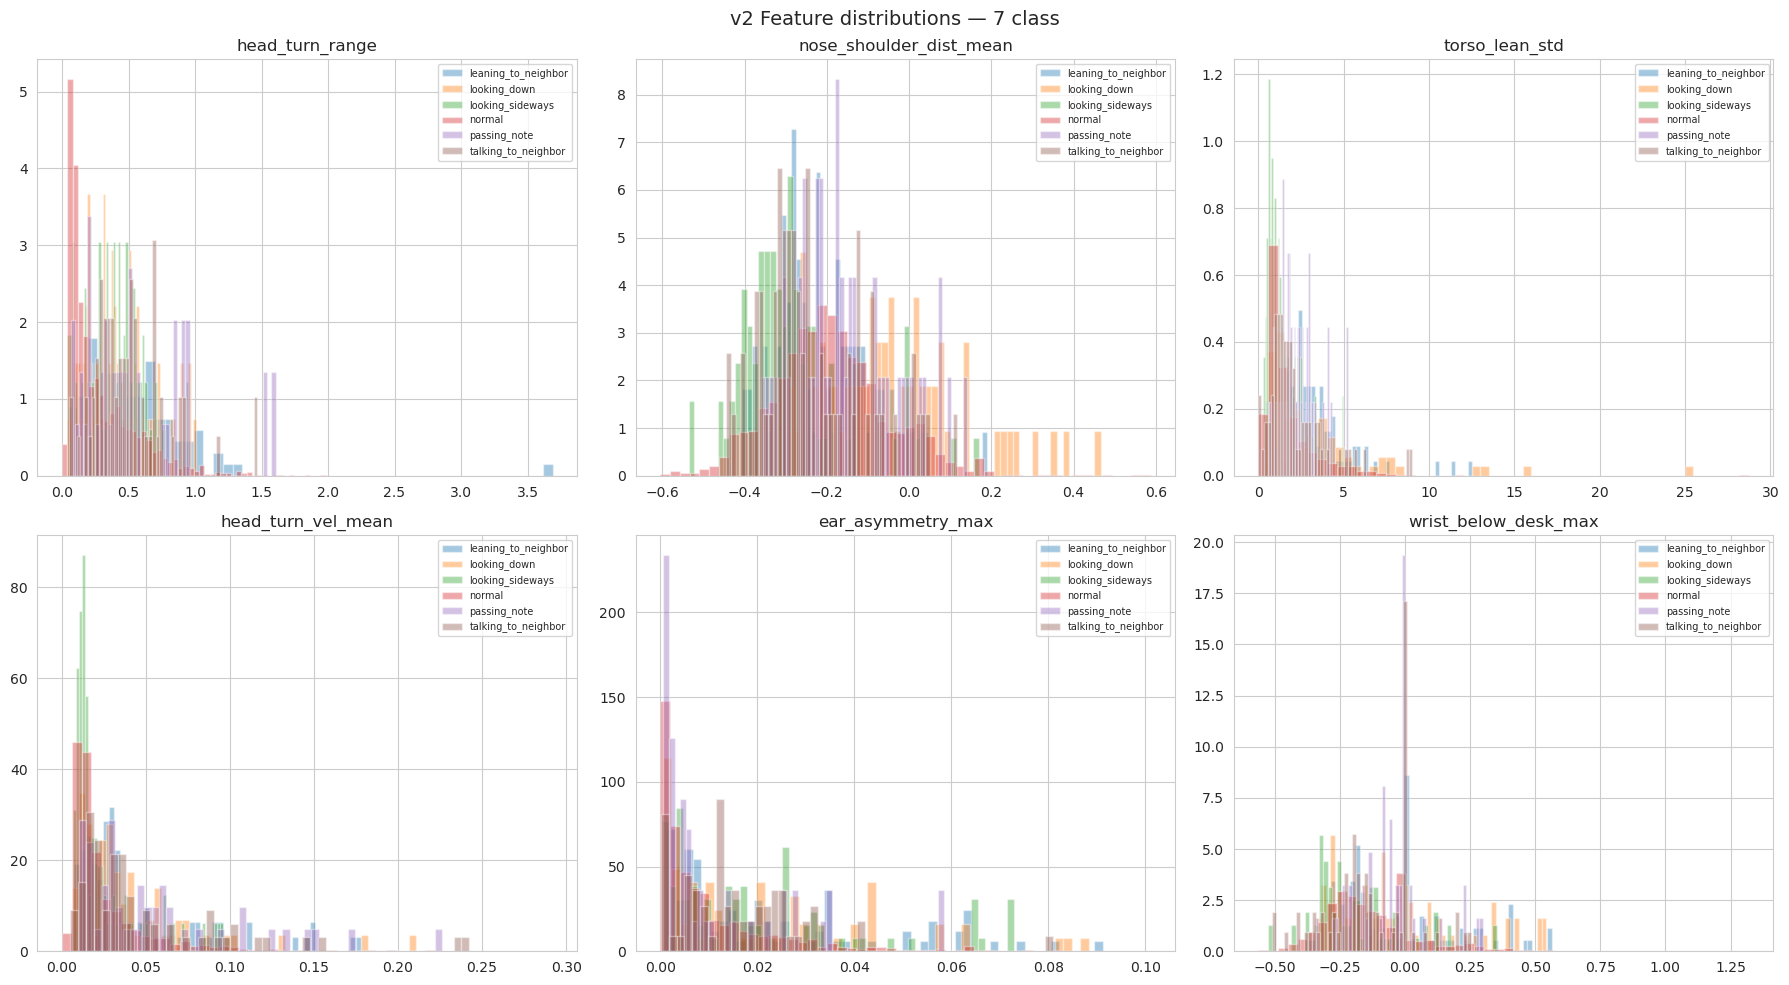

In [14]:
# 6-class distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, fn in zip(axes.flat, key_feats):
    for cls in sorted(df_feat['label_7'].unique()):
        m = df_feat['label_7'] == cls
        if m.sum() > 0:
            ax.hist(df_feat.loc[m, fn], bins=50, alpha=0.4, label=cls, density=True)
    ax.set_title(fn); ax.legend(fontsize=7)
plt.suptitle('v2 Feature distributions — 7 class', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'v2_7class_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Feature importance
nor_m = df_feat[df_feat['label_2']=='normal'][FULL_FEAT_NAMES].mean()
nor_s = df_feat[df_feat['label_2']=='normal'][FULL_FEAT_NAMES].std().replace(0,1)
sus_m = df_feat[df_feat['label_2']=='suspicious'][FULL_FEAT_NAMES].mean()
effect = ((sus_m - nor_m) / nor_s).abs().sort_values(ascending=False)
print('Top 10 features separating normal from suspicious:\n')
for f, v in effect.head(10).items():
    d = 'higher' if sus_m[f] > nor_m[f] else 'lower'
    print(f'  {f}: effect={v:.3f} ({d})')

print(f'\n\nPer suspicious class:')
for cls in sorted(set(all_labels_7) - {'normal'}):
    cls_m = df_feat[df_feat['label_7']==cls][FULL_FEAT_NAMES].mean()
    eff = ((cls_m - nor_m) / nor_s).abs().sort_values(ascending=False)
    print(f'\n  {cls}:')
    for f, v in eff.head(3).items():
        print(f'    {f}: effect={v:.3f}')

Top 10 features separating normal from suspicious:

  head_turn_std: effect=0.768 (higher)
  head_turn_range: effect=0.739 (higher)
  ear_asymmetry_std: effect=0.637 (higher)
  ear_asymmetry_range: effect=0.633 (higher)
  ear_asymmetry_max: effect=0.628 (higher)
  l_wrist_extent_std: effect=0.608 (higher)
  l_wrist_extent_range: effect=0.594 (higher)
  r_wrist_extent_range: effect=0.546 (higher)
  r_wrist_extent_std: effect=0.537 (higher)
  head_turn_vel_range: effect=0.534 (higher)


Per suspicious class:

  leaning_to_neighbor:
    head_turn_range: effect=1.038
    head_turn_std: effect=1.033
    l_wrist_extent_std: effect=1.026

  looking_down:
    torso_lean_range: effect=1.209
    nose_shoulder_dist_max: effect=1.182
    nose_shoulder_dist_mean: effect=1.095

  looking_sideways:
    ear_asymmetry_std: effect=0.751
    ear_asymmetry_range: effect=0.722
    nose_shoulder_dist_mean: effect=0.706

  passing_note:
    l_wrist_extent_range: effect=2.214
    l_wrist_extent_std: effect=2.